In [8]:
from sklearn.metrics import euclidean_distances
from sklearn.utils import check_random_state
import scipy.sparse as sp

def gp_network(n_nodes=100, n_time_steps=100, n_features=2, sparse=True, density=0.2, random_state=42):
    rng = check_random_state(random_state)
    ts = np.arange(n_time_steps)
    dist_sq = euclidean_distances(ts[:, None], squared=True)
    ls = (4./n_time_steps) ** 2
    C = np.exp(-0.5 * dist_sq * ls )
    X = rng.multivariate_normal(np.zeros_like(ts), cov=C, size=(n_nodes, n_features)).transpose((2, 0, 1))
                
    
    means = []
    subdiag = np.tril_indices(n_nodes, k=-1)
    for t in range(n_time_steps):
        means.append((X[t] @ X[t].T)[subdiag])
  
    Ys = []    
    for t in range(n_time_steps):
        Y = np.zeros((n_nodes, n_nodes))

        X[t] *= np.sqrt(density) 
        y = means[t] + np.sqrt(2) * rng.randn(*means[t].shape)
        
        zif_mask = rng.binomial(1, density * np.ones_like(y))
        y = zif_mask * y
    

        Y[subdiag] = y
        Y += Y.T
        
        Y = sp.csr_array(Y, dtype=float) if sparse else Y.astype(float)
        Ys.append(Y)

    Y = Ys if sparse else np.dstack(Ys).transpose((2, 0, 1))
    
    return Y, X, np.stack(means)
    

4.766568384237217e-05


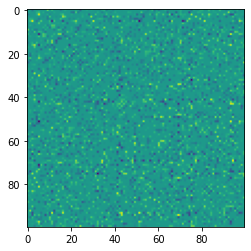

In [30]:
Y, X, means = gp_network(n_nodes=100, n_time_steps=100, sparse=True, density=0.5)

print(np.mean([Yt.mean() for Yt in Y]))
plt.imshow(Y[-1].toarray(), cmap='viridis_r')

In [31]:
from dynrdpg import DynamicRDPG

dase = DynamicRDPG(is_binary=False, rw_order=2, random_state=13)
dase.sample(Y, n_burnin=1000, n_samples=1000)

100%|█████████████████████████████████████████████████████████████████| 2000/2000 [09:06<00:00,  3.66it/s]


0.013490153064226393

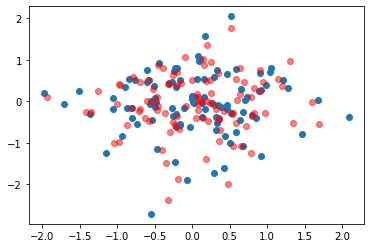

In [32]:
from scipy.linalg import orthogonal_procrustes

t = -1
X_dase = dase.X_[t]
R, _ = orthogonal_procrustes(X_dase, X[t])
X_dase = X_dase @ R
plt.scatter(X_dase[:, 0], X_dase[:, 1])
plt.scatter(X[t][:, 0], X[t][:, 1], c='red', alpha=0.5)

subdiag = np.tril_indices_from(Y[t], k=-1)

#print(roc_auc_score(Y[t][subdiag], dase.probas_[t]))
np.mean((X_dase - X[t]) ** 2)

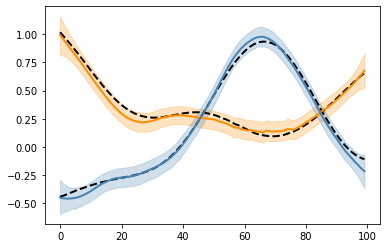

In [37]:
idx = 10

#print(np.sqrt(dase.sigma_[idx]))
X_est = dase.X_.copy()#np.mean(dase.samples_['X'], axis=0)
X_true = X.copy() 
for t in range(len(Y)):
    R, _ = orthogonal_procrustes(X_true[t], X_est[t])
    X_true[t] = X_true[t] @ R
    
plt.plot(X_true[:, idx], '--', lw=2, color='k')

cis = np.quantile(dase.samples_['X'][:, :, idx], q=[0.025, 0.975], axis=0)
plt.plot(X_est[:, idx, 1], '-', color='darkorange', lw=2)
plt.plot(X_est[:, idx, 0], '-', color='steelblue', lw=2)
plt.fill_between(np.arange(len(Y)), cis[0, :, 1], cis[1, :, 1], color='darkorange', alpha=0.25)
plt.fill_between(np.arange(len(Y)), cis[0, :, 0], cis[1, :, 0], color='steelblue', alpha=0.25)